<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB38 · Centro de masas y equilibrio quieto

**Parte 5 · La física del cuerpo — Lección 3**

> En el **NB37** dedujiste la ecuación de un palo que se cae y viste que la gravedad actúa como si todo el peso estuviera en un único punto: el **centro de masas**.

Hoy ese punto es el protagonista. Es, probablemente, **el punto más importante de un robot con patas**. Casi todo lo que se dice sobre el equilibrio de un robot (que si "está estable", que si "se va a caer", que si "tiene que adelantar el pie") es, en el fondo, una frase sobre dónde está su centro de masas.

Vamos a aprender a **calcularlo** (para una pieza, para dos, para un robot entero), lo vamos a medir en Hopper con MuJoCo y vamos a descubrir la **regla de oro del equilibrio quieto**. Después la pondremos a prueba con dos experimentos: un bloque que vuelca o no según su inclinación, y un Hopper convertido en **estatua** que se mantiene de pie... o se cae de bruces.


## 1 · El balancín

Empecemos en el parque. Un **balancín** (o sube y baja): una tabla apoyada en el centro, con un niño en cada lado.

- Si los dos niños pesan **lo mismo** y se sientan a la **misma distancia** del centro, el balancín queda **equilibrado**.
- Si uno pesa **más**, su lado baja. Para equilibrarlo, el más pesado tiene que sentarse **más cerca** del centro.

¿Cuánto más cerca, exactamente? Con el **par** del NB37 lo sabemos. Cada niño hace un par alrededor del apoyo: su peso por su distancia (su brazo de palanca). El balancín está equilibrado cuando los dos pares son **iguales**:

```
   masa₁ × distancia₁  =  masa₂ × distancia₂

          30 kg                                45 kg
           🧒                                    🧒
   ═══════════════════════════▲═══════════════════════════
           │◄──── 1,5 m ──────►│◄─── ? ───►│
```

(La g del peso está en los dos lados y se va, por eso basta con las masas.) Un niño de 30 kg a 1,5 m. ¿Dónde se sienta el de 45 kg?


In [1]:
print(30 * 1.5 / 45, "m")

1.0 m


A **1 metro** del centro. El niño que pesa 1,5 veces más se sienta a una distancia 1,5 veces menor. Esta es la **ley de la palanca** de Arquímedes, la misma de la llave inglesa del NB37.


## 2 · El centro de masas: una media "con peso"

Ahora cambiemos la pregunta. Los niños ya están sentados donde quieran; ¿**dónde habría que poner el apoyo** para que el balancín quede equilibrado? Ese punto es el **centro de masas** de los dos niños.

Pongamos una regla a lo largo del balancín: el niño de 30 kg en la posición **x = −1,5** (a la izquierda) y el de 45 kg en **x = 1** (a la derecha). La fórmula del centro de masas es una **media**, pero una media especial:

```
             masa₁ × x₁  +  masa₂ × x₂
   x_CdM  =  ──────────────────────────
                 masa₁  +  masa₂
```

Es como la media de las notas de clase, pero en la que cada posición cuenta **tanto como su masa**. A eso se le llama **media ponderada** ("ponderar" = dar peso). Una media normal de −1,5 y 1 daría −0,25; la ponderada se va hacia el niño **pesado**:


In [2]:
masas = [30, 45]
posiciones = [-1.5, 1.0]

x_cdm = (masas[0] * posiciones[0] + masas[1] * posiciones[1]) / (masas[0] + masas[1])
print(x_cdm)

0.0


**0**: justo en el centro del balancín, donde estaba el apoyo cuando los colocamos en el apartado anterior. Las dos ideas son **la misma**:

> Un objeto apoyado en un punto está en equilibrio **cuando su centro de masas está justo encima del apoyo**.

Si el centro de masas está a un lado del apoyo, el peso hace par hacia ese lado, y el objeto gira (cae) hacia allí.


### Muchas piezas

Con más piezas, la fórmula es la misma: sumar "masa × posición" de **todas** las piezas y dividir entre la masa **total**. Con NumPy (NB15) es una línea, para cualquier número de piezas. Añadamos un tercer niño, de 20 kg, en x = 2:


In [3]:
import numpy as np

masas = np.array([30, 45, 20])
posiciones = np.array([-1.5, 1.0, 2.0])

print(np.sum(masas * posiciones) / np.sum(masas))

0.42105263157894735


El centro de masas se ha ido hacia la derecha, a **0,42 m**, hacia donde se ha sentado el nuevo niño. Para equilibrar el balancín, habría que mover el apoyo ahí.

### En el plano: cada coordenada por separado

Un robot no está en una línea, sino en el espacio. Pero la regla funciona **igual para cada coordenada por separado** (como las flechas del NB12): la x del centro de masas es la media ponderada de las x; la altura, la media ponderada de las alturas. Sin más.


## 3 · El centro de masas de Hopper

Vamos a calcular el centro de masas de Hopper **pieza a pieza**, como con los niños. MuJoCo nos da los dos ingredientes:

- `modelo.body_mass`: la **masa** de cada pieza (NB35).
- `datos.xipos`: dónde está el **centro de masas de cada pieza** en el mundo (cada pieza tiene el suyo; la **i** es de *inertia*, inercia). Tres coordenadas: x (delante), y (lado), z (altura).

Primero, Hopper de pie y recto, como en el NB36:


In [4]:
import os
os.environ["MUJOCO_GL"] = "egl"
import gymnasium as gym
import mujoco

hopper = gym.make("Hopper-v5")
hopper.reset(seed=0)
modelo = hopper.unwrapped.model
datos = hopper.unwrapped.data

datos.qpos[:] = [0.0, 1.25, 0.0, 0.0, 0.0, 0.0]     # de pie y recto
mujoco.mj_forward(modelo, datos)

In [5]:
nombres = ["mundo", "torso", "muslo", "pierna", "pie"]
for i in range(1, 5):
    print(f"{nombres[i]:>6}: {modelo.body_mass[i]:5.2f} kg   centro en x = {datos.xipos[i][0]:+.3f}, altura = {datos.xipos[i][2]:.3f}")

 torso:  3.67 kg   centro en x = +0.000, altura = 1.250
 muslo:  4.06 kg   centro en x = +0.000, altura = 0.825
pierna:  2.78 kg   centro en x = +0.000, altura = 0.350
   pie:  5.32 kg   centro en x = +0.065, altura = 0.100


(Empezamos en 1 porque la pieza 0 es el mundo, con masa 0.) Fíjate en dos cosas:

- La pieza más pesada es el **pie** (5,3 kg). Raro para un humano, pero útil para un robot: masa **abajo**, como un tentetieso.
- El centro del pie está **por delante** (x = +0,065): el pie se extiende más hacia delante que hacia atrás del tobillo.

Ahora, la media ponderada, para la x y para la altura:


In [6]:
masas_hopper = modelo.body_mass[1:]
x_piezas = datos.xipos[1:, 0]          # la columna 0 (la x) de las filas 1 a 4
z_piezas = datos.xipos[1:, 2]          # la columna 2 (la altura)

x_cdm = np.sum(masas_hopper * x_piezas) / np.sum(masas_hopper)
z_cdm = np.sum(masas_hopper * z_piezas) / np.sum(masas_hopper)
print(f"centro de masas de Hopper: x = {x_cdm:+.4f} m, altura = {z_cdm:.4f} m")

centro de masas de Hopper: x = +0.0218 m, altura = 0.5964 m


(`datos.xipos[1:, 0]` usa la indexación de NumPy del NB27: filas de la 1 en adelante, columna 0.)

El centro de masas de Hopper, de pie, está a **0,60 m** de altura y **2 cm por delante** del tobillo (que está en x = 0). Hacia delante por culpa de ese pie pesado que sobresale por delante.

MuJoCo también calcula el centro de masas del robot entero, en `datos.subtree_com` ("centro de masas del subárbol": de una pieza y todo lo que cuelga de ella; el torso es la raíz de Hopper, así que el subárbol del torso es el robot entero):


In [7]:
print("MuJoCo:", datos.subtree_com[1].round(4))

MuJoCo: [0.0218 0.     0.5964]


Las mismas x y altura que nuestra media ponderada (la del medio es la y, de lado, que en un robot plano siempre es 0).


### El centro de masas se mueve

Un detalle crucial: el centro de masas **no** está pegado a ninguna pieza. Es una media, así que **se mueve cuando el robot cambia de postura**. Hagamos una función que coloca a Hopper en una postura y devuelve su centro de masas:


In [8]:
def centro_de_masas(cadera, rodilla, tobillo):
    datos.qpos[:] = [0.0, 1.25, 0.0, cadera, rodilla, tobillo]
    mujoco.mj_forward(modelo, datos)
    return datos.subtree_com[1][0], datos.subtree_com[1][2]      # x y altura

In [9]:
for postura in [(0, 0, 0), (0, -1.2, 0), (-0.8, -1.2, 0)]:
    x, z = centro_de_masas(*postura)
    print(f"cadera {postura[0]:+.1f}, rodilla {postura[1]:+.1f}:  CdM en x = {x:+.3f}, altura = {z:.3f}")

cadera +0.0, rodilla +0.0:  CdM en x = +0.022, altura = 0.596
cadera +0.0, rodilla -1.2:  CdM en x = -0.190, altura = 0.711
cadera -0.8, rodilla -1.2:  CdM en x = -0.408, altura = 0.964


(El asterisco de `centro_de_masas(*postura)` "desempaqueta" la tupla en tres argumentos, NB23.)

- Recto: CdM 2 cm por delante de la cadera, a 0,60 m de altura.
- Rodilla doblada (pie hacia atrás): el CdM se va **19 cm hacia atrás** y **sube** a 0,71 m (el pie, que pesa mucho, se ha levantado).
- Además, cadera hacia atrás: el CdM se va **todavía más atrás**, a 41 cm, y sube hasta 0,96 m.

Cada vez que un robot mueve una pierna, mueve su centro de masas. Andar es, en buena parte, **llevar el centro de masas de un sitio a otro** sin que se escape.


## 4 · La base de apoyo

El otro protagonista del equilibrio es la **base de apoyo**: la zona del suelo "abarcada" por los puntos en los que el robot **toca** el suelo.

- **Hopper** (un robot plano, que vive en un dibujo de perfil): su base de apoyo es el **segmento** que ocupa su pie sobre el suelo, desde el **talón** hasta la **punta**. En su plano (NB36, ejercicio E7), el pie va de **13 cm por detrás** del tobillo a **26 cm por delante**.
- **Walker2d** con los dos pies en el suelo: el segmento que va desde el talón del pie de atrás hasta la punta del pie de delante.
- **Un humano o un humanoide en 3D**: imagina que pones una **goma elástica** alrededor de los dos pies, rodeándolos por fuera. La zona encerrada por la goma es su base de apoyo (los matemáticos la llaman **envolvente convexa**).

```
     Con los pies juntos:          Con los pies separados:        Sobre un pie:
       ┌──┬──┐                      ┌──┐          ┌──┐              ┌──┐
       │  │  │                      │  │╲________╱│  │              │  │
       │  │  │                      │  │          │  │              │  │
       │  │  │                      │  │╱‾‾‾‾‾‾‾‾╲│  │              │  │
       └──┴──┘                      └──┘          └──┘              └──┘
     base pequeña                base grande (la goma             base mínima:
                                 abarca el hueco del medio)       solo un pie
```

Por eso, cuando alguien te empuja, abres las piernas **sin pensarlo**: agrandas tu base de apoyo. Y por eso es tan difícil mantenerse sobre un pie: la base es diminuta.


## 5 · La regla de oro del equilibrio quieto

Juntemos las dos piezas. La regla es:

> **Un objeto quieto no se cae mientras la vertical de su centro de masas caiga dentro de su base de apoyo.**

"La vertical del centro de masas" es el punto del suelo que queda **justo debajo** del centro de masas: donde caería una plomada (una cuerda con un peso) colgada de él.

¿Por qué? Piensa en lo que pasa cuando el centro de masas está **fuera**, por ejemplo por delante de la punta del pie:

```
                 ✚  centro de masas
                 │
      ┌───────┐  │  peso
      │  pie  │  ▼
   ───┴───────●─────────  suelo
              ▲
          la punta: el último punto de apoyo
```

El objeto solo puede girar alrededor del **último punto que toca el suelo**: la punta del pie. El peso, aplicado en el centro de masas, que está **más allá** de la punta, hace un **par** (NB37) que lo hace girar hacia delante, hacia el suelo. ¿Puede algo pararlo? El suelo solo puede **empujar** hacia arriba (fuerza normal, NB37), y lo hace en los puntos de la base de apoyo, que están todos **detrás** del centro de masas: empujando ahí, el suelo no puede crear un par que compense. Y el suelo **no puede tirar** del pie hacia abajo (no es pegamento). Así que nada compensa el par del peso: el objeto vuelca.

En cambio, si el centro de masas está **dentro** de la base, el suelo empuja un poco más con unas partes del pie que con otras (más con la punta si el CdM está hacia delante, más con el talón si está hacia atrás) y compensa el par. El objeto se queda quieto.


## 6 · Experimento 1: el bloque que vuelca

Pongamos la regla a prueba con el objeto más sencillo posible: un **bloque** de 20 cm de ancho y 60 cm de alto (como una caja de cereales gigante), apoyado en una de sus aristas e **inclinado** un ángulo θ. Lo soltamos y miramos: ¿vuelve a ponerse derecho o vuelca?

```
        derecho               inclinado θ, apoyado en la arista
        ┌───┐                         ╱╲
        │   │                        ╱  ╲
        │ ✚ │  ← CdM en el centro   ╱ ✚  ╲
        │   │                      ╲    ╱
        └───┘                       ╲  ╱
                                     ●  ← la arista (base de apoyo: un punto)
```

Apoyado en la arista, su base de apoyo es **ese punto**. Si la vertical del centro de masas cae del lado del bloque, la gravedad lo devuelve a su sitio; si cae del otro lado, vuelca. El momento justo es cuando el centro de masas está **exactamente encima** de la arista: la diagonal que va de la arista al centro del bloque está **vertical**. Esa diagonal sube 30 cm (medio alto) mientras se va 10 cm hacia el lado (medio ancho), y con el `atan2` del NB36 obtenemos su ángulo:


In [10]:
import math

medio_ancho, medio_alto = 0.10, 0.30
angulo_critico = math.degrees(math.atan2(medio_ancho, medio_alto))
print(round(angulo_critico, 1), "grados")

18.4 grados


(Aquí `atan2(lado, altura)` da el ángulo **desde la vertical**, con las coordenadas cambiadas de papel, igual que el seno y el coseno se cambiaban de papel en el NB36, sección 7.)

**18,4°**. La regla predice: inclinado menos de 18,4°, vuelve; inclinado más, vuelca. Que lo diga MuJoCo. Escribimos un plano con un suelo y un bloque libre (una `freejoint`: una "articulación" que deja a la pieza moverse y girar en todas direcciones, como un objeto suelto), inclinado θ grados con `euler` y colocado con la arista justo encima del suelo:


In [11]:
def soltar_bloque(grados):
    theta = math.radians(grados)
    altura = medio_ancho * math.sin(theta) + medio_alto * math.cos(theta) + 0.002   # la arista, a 2 mm del suelo
    plano = f'''
    <mujoco>
      <option timestep="0.001"/>
      <worldbody>
        <geom type="plane" size="5 5 0.1"/>
        <body pos="0 0 {altura}" euler="0 {grados} 0">
          <freejoint/>
          <geom type="box" size="{medio_ancho} 0.1 {medio_alto}" mass="1"/>
        </body>
      </worldbody>
    </mujoco>'''
    m = mujoco.MjModel.from_xml_string(plano)
    d = mujoco.MjData(m)
    for paso in range(3000):                                        # 3 segundos
        mujoco.mj_step(m, d)
    return d.xpos[1][2]                                              # altura final del centro del bloque

(La `f` delante del texto es el f-string del NB20: mete los valores de `altura` y `grados` dentro del plano. El `size` de una caja en MuJoCo son las **mitades** de sus medidas. Y la función devuelve la altura final del centro del bloque: **0,30 m** si ha quedado de pie, **0,10 m** si ha quedado tumbado.) Probemos varias inclinaciones alrededor de 18,4°:

In [12]:
for grados in [10, 15, 18, 19, 25]:
    altura = soltar_bloque(grados)
    print(f"{grados:2d}°: centro a {altura:.2f} m  →  {'vuelve a ponerse de pie' if altura > 0.2 else 'VUELCA'}")

10°: centro a 0.30 m  →  vuelve a ponerse de pie
15°: centro a 0.30 m  →  vuelve a ponerse de pie
18°: centro a 0.30 m  →  vuelve a ponerse de pie


19°: centro a 0.10 m  →  VUELCA


25°: centro a 0.10 m  →  VUELCA


Exactamente lo que predice la regla: a **18°** (el CdM aún no ha pasado de la arista) el bloque **vuelve**; a **19°** (ya ha pasado), **vuelca**. La frontera está entre los dos, donde dijimos: 18,4°.

Fíjate en cómo cambia el ángulo crítico con la forma del bloque: un bloque **ancho y bajo** (CdM bajo, base ancha) aguanta inclinaciones enormes; uno **estrecho y alto**, casi nada. Por eso los coches de carreras son bajos y anchos, y por eso un camión cargado muy alto vuelca en las curvas. Lo calcularás en el ejercicio E3.


## 7 · Experimento 2: Hopper convertido en estatua

Ahora, con el robot de verdad. Pero hay un problema: si soltamos a Hopper sin mover sus motores, sus articulaciones están **sueltas** y se desploma como un muñeco de trapo (NB35). Para estudiar el equilibrio quieto necesitamos que mantenga una postura fija, como una **estatua**.

Un truco de laboratorio: convertimos sus articulaciones en **muelles muy duros**. MuJoCo lo permite con dos números por articulación:

- `jnt_stiffness` (**rigidez**): lo duro que es el muelle. Cuanto mayor, más se resiste a doblarse.
- `qpos_spring`: la postura en la que el muelle está **relajado**. Si la articulación se aparta de ella, el muelle la devuelve.

Con muelles muy duros, Hopper mantiene la postura que le digamos, como si fuera de una sola pieza. (Y `dof_damping`, la **amortiguación**, frena las vibraciones del muelle, como los amortiguadores de un coche.) Atención: esto **no** es control, es hacer trampa con el robot para estudiar la física. En el NB40 aprenderemos cómo un **motor** de verdad puede hacer lo mismo.

La postura que vamos a probar: Hopper con el torso recto, la pierna **inclinada hacia atrás** un ángulo h (la cadera a −h) y el pie **plano** en el suelo (el tobillo a +h, para que los ángulos sumen 0: NB36). Cuanto mayor h, más **por delante** del pie queda el torso, y con él el centro de masas:

```
   (hacia delante = hacia la derecha)

       h = 0                 h = 0,3                 h = 0,6
         ┃ torso                   ┃                         ┃
         ┃                        ╱                        ╱
         ┃ pierna                ╱                       ╱
         ┃                      ╱                      ╱
       ══╧══ pie             ══╧══                  ══╧══
```

(La pierna se inclina hacia **atrás**, así que el pie se queda atrás y el torso, por delante del pie.)


In [13]:
def estatua(h, pasos=1500):
    hopper.reset(seed=0)
    postura = [-h, 0.0, h]
    modelo.jnt_stiffness[3:6] = 3000          # articulaciones 3, 4 y 5: cadera, rodilla, tobillo
    modelo.qpos_spring[3:6] = postura
    modelo.dof_damping[3:6] = 60
    datos.qpos[:] = [0.0, 1.25, 0.0, *postura]
    datos.qvel[:] = 0
    mujoco.mj_forward(modelo, datos)
    # bajamos el robot hasta que el pie toque el suelo (el pie tiene 6 cm de grosor por debajo del tobillo)
    datos.qpos[1] -= datos.joint("foot_joint").xanchor[2] - 0.0605
    mujoco.mj_forward(modelo, datos)
    cdm_respecto_tobillo = datos.subtree_com[1][0] - datos.joint("foot_joint").xanchor[0]
    for paso in range(pasos):                  # 1500 pasitos de 0,002 s = 3 segundos
        mujoco.mj_step(modelo, datos)
    return cdm_respecto_tobillo, datos.qpos[2]      # dónde estaba el CdM, y cuánto acabó inclinado el torso

La función coloca la estatua, la apoya en el suelo, apunta **dónde está su centro de masas respecto del tobillo** y la deja 3 segundos a su suerte. Devuelve esa posición del CdM y la **inclinación final** del torso (`qpos[2]`): cerca de 0 si sigue de pie; más de 1 radián si se ha caído.

Recuerda la base de apoyo de Hopper: de **−0,13** (talón) a **+0,26** (punta) respecto del tobillo. Tres estatuas:


In [14]:
for h in [0.0, 0.3, 0.6]:
    cdm, inclinacion = estatua(h)
    estado = "DE PIE" if abs(inclinacion) < 0.5 else "SE CAE"
    print(f"h = {h:.1f}: CdM {cdm:+.3f} m respecto del tobillo (base: de -0,13 a +0,26)  →  inclinación final {inclinacion:+.2f} rad  {estado}")

h = 0.0: CdM +0.022 m respecto del tobillo (base: de -0,13 a +0,26)  →  inclinación final -0.01 rad  DE PIE


h = 0.3: CdM +0.155 m respecto del tobillo (base: de -0,13 a +0,26)  →  inclinación final +0.02 rad  DE PIE


h = 0.6: CdM +0.276 m respecto del tobillo (base: de -0,13 a +0,26)  →  inclinación final +1.24 rad  SE CAE


- **h = 0**: el CdM está 2 cm por delante del tobillo, bien dentro de la base. **De pie.**
- **h = 0,3**: el CdM se ha ido 15 cm hacia delante, pero sigue dentro. **De pie.**
- **h = 0,6**: el CdM está a **27,6 cm** del tobillo, **más allá de la punta** del pie (26 cm). **Se cae de bruces**: el torso acaba inclinado más de 1,2 radianes.

¡La regla funciona con el robot de verdad! Veámoslo. Grabamos una foto final de cada estatua con el `Renderer` de MuJoCo (la cámara del NB15):


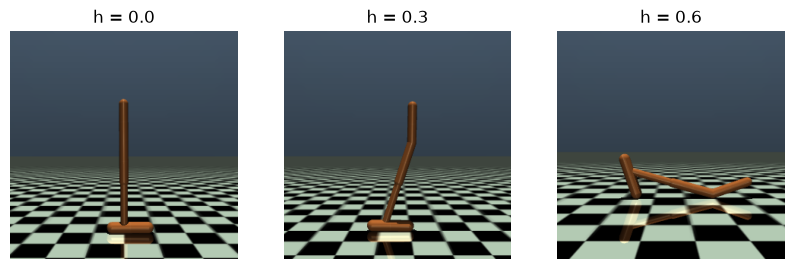

In [15]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 3, figsize=(10, 3.6))
with mujoco.Renderer(modelo, height=300, width=300) as camara:
    for eje, h in zip(ejes, [0.0, 0.3, 0.6]):
        estatua(h)
        camara.update_scene(datos, camera="track")
        eje.imshow(camara.render())
        eje.set_title(f"h = {h}")
        eje.axis("off")
plt.show()

(`plt.subplots(1, 3)` crea una fila de tres dibujos, y `zip` recorre a la vez los dibujos y las h, NB21. `camera="track"` es la cámara que sigue al robot.)


### ¿Dónde está exactamente el límite?

La teoría dice: se cae cuando el CdM pasa de **+0,26**. Busquemos el límite de verdad probando muchas h:

In [16]:
for h in np.arange(0.36, 0.58, 0.04):
    cdm, inclinacion = estatua(h)
    print(f"h = {h:.2f}: CdM {cdm:+.3f}  →  {'de pie' if abs(inclinacion) < 0.5 else 'SE CAE'}")

h = 0.36: CdM +0.180  →  de pie
h = 0.40: CdM +0.197  →  de pie
h = 0.44: CdM +0.214  →  de pie
h = 0.48: CdM +0.230  →  SE CAE


h = 0.52: CdM +0.245  →  SE CAE
h = 0.56: CdM +0.261  →  SE CAE


¡Sorpresa! Aguanta con el CdM a 21 cm, pero se cae con el CdM a **23 cm**: el límite está hacia los **22 cm**, antes de llegar a la punta (26 cm). ¿Está mal la regla? No: la regla es para un objeto **perfectamente rígido** sobre un suelo **perfectamente duro**. Nuestra estatua no lo es del todo:

- Sus articulaciones son **muelles**: muy duros, pero ceden un poquito con el peso, y al ceder, el torso se inclina un pelín hacia delante y **el CdM avanza** respecto de lo que habíamos calculado con la postura exacta.
- El **suelo** de MuJoCo es ligeramente **blando** (para poder calcular los choques, deja que los objetos se hundan una fracción de milímetro), y la **punta del pie** es **redondeada** (el pie es una cápsula, NB35): cerca de la punta, el pie puede **rodar** en vez de apoyarse de plano.

Las dos cosas hacen que el borde **útil** de la base sea un poco más corto que el borde **geométrico**. Y esto no es un defecto del simulador: en un robot real pasa lo mismo, y **más** (motores que ceden, suelas de goma, suelos irregulares). Por eso los ingenieros nunca diseñan para que el CdM esté justo en el borde: dejan un **margen de seguridad**, y se considera que un robot está "cómodo" cuando su CdM está bien **dentro** de la base, lejos de los bordes.


## 8 · Equilibrio quieto y equilibrio en movimiento

Todo lo de hoy es **equilibrio estático** (quieto): un objeto que **no se mueve** no se cae si la vertical de su CdM está dentro de la base.

Y ahora, una pregunta incómoda. Cuando **tú** andas, ¿tu centro de masas está siempre encima de tu base de apoyo? Haz la prueba: da un paso **muy despacio**, parándote a mitad. Notarás que, para poder pararte, tienes que llevar el peso encima del pie de delante **antes** de levantar el de atrás. Si andas normal, no lo haces: mientras el pie de delante va por el aire, tu centro de masas ya está **por delante** de tu pie de apoyo. Si te congelaran en ese instante, **te caerías**. Andar es, literalmente, **caerse hacia delante y poner el pie a tiempo** (¿te acuerdas del Walker2d del NB35, que andaba "cayéndose hacia delante"?).

Los robots que andan siempre con el CdM dentro de la base (**marcha estática**) existen, pero son lentísimos: los primeros robots bípedos de los años 70 y 80 andaban así, tardando varios segundos en cada paso. Para andar deprisa hace falta **equilibrio dinámico**: estar "cayéndose" de forma controlada. Ahí la regla de hoy ya no basta, porque importa también **la velocidad** del centro de masas. Eso es el NB39: el péndulo invertido lineal, el **punto de captura** ("dónde tengo que poner el pie para no caerme") y el **ZMP**.


## 9 · Resumen de la lección

1. **Balancín**: equilibrado cuando los pares son iguales (masa₁ × distancia₁ = masa₂ × distancia₂, ley de la palanca).
2. **Centro de masas** = **media ponderada** de las posiciones, con las masas como pesos: Σ(masa × posición) / Σ masa. En el plano o el espacio, cada coordenada por separado.
3. Un objeto apoyado en un punto está en equilibrio cuando su CdM está **justo encima** del apoyo.
4. El CdM de Hopper (de pie) está a 0,60 m de altura y 2 cm por delante del tobillo; lo calculamos con `body_mass` y `xipos` y coincide con `subtree_com`. **El CdM se mueve** al cambiar de postura.
5. **Base de apoyo**: la zona abarcada por los puntos que tocan el suelo (segmento en un robot plano; "goma elástica" alrededor de los pies en 3D).
6. **Regla del equilibrio quieto**: no se cae mientras la vertical del CdM esté **dentro** de la base. Si sale, el peso hace un par sobre el borde que el suelo no puede compensar (empuja, pero no tira).
7. Bloque en MuJoCo: ángulo crítico = atan2(medio ancho, medio alto) = 18,4°; 18° vuelve, 19° vuelca. Bajo y ancho = más estable.
8. Hopper-estatua (muelles en las articulaciones): de pie con el CdM sobre el pie, se cae de bruces con el CdM más allá de la punta. El límite real (~22 cm) es menor que el geométrico (26 cm): **margen de seguridad**.
9. Andar deprisa es **equilibrio dinámico**: el CdM sale de la base y el pie llega a tiempo. Próximo notebook.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Ley de la palanca** | masa₁ × distancia₁ = masa₂ × distancia₂ en equilibrio. |
| **Media ponderada** | Media en la que cada valor cuenta según su peso (aquí, su masa). |
| **Centro de masas (CdM)** | La media ponderada de las posiciones de toda la masa; donde "actúa" el peso. |
| **`xipos` / `subtree_com`** | En MuJoCo: el CdM de cada pieza / el de una pieza y todo lo que cuelga de ella. |
| **Base de apoyo** | Zona del suelo abarcada por los puntos de contacto. |
| **Envolvente convexa** | La forma que tomaría una goma elástica alrededor de unos puntos. |
| **Vertical del CdM** | El punto del suelo justo debajo del CdM. |
| **Ángulo crítico** | Inclinación a partir de la cual un objeto vuelca. |
| **`freejoint`** | En MuJoCo, una pieza suelta que se mueve y gira libremente. |
| **Rigidez / amortiguación** | Lo duro que es un muelle / lo que frena sus vibraciones. |
| **Margen de seguridad** | Distancia que se deja entre el CdM y el borde de la base. |
| **Equilibrio estático / dinámico** | Quieto, con el CdM sobre la base / en movimiento, "cayéndose" de forma controlada. |
| **Marcha estática** | Andar con el CdM siempre sobre la base: estable, pero lentísimo. |


## 10 · Ejercicios

**E1.** Un niño de 25 kg se sienta a 2 m del centro de un balancín. ¿Dónde tiene que sentarse su padre, de 75 kg, para equilibrarlo? ¿Podría equilibrarlo si el balancín solo midiera 0,5 m por cada lado?

**E2.** Calcula el centro de masas (x) de tres piezas: 2 kg en x = 0, 3 kg en x = 1 y 5 kg en x = 4. Primero a mano, luego con NumPy.

**E3.** Calcula el ángulo crítico de un bloque de 1 m de ancho y 0,5 m de alto (bajo y ancho, como un coche de carreras) y el de uno de 0,1 m de ancho y 1 m de alto (como una botella). ¿Cuál es más difícil de volcar?

**E4.** Con la función `centro_de_masas`, busca una postura de Hopper en la que el CdM esté **por detrás del talón** (más atrás de −0,13 respecto del tobillo). Pista: con la cadera y la rodilla a 0, el tobillo está justo debajo de la cadera (x = 0); con otras posturas, el tobillo se mueve, así que calcula la posición del CdM **respecto del tobillo** con `datos.joint("foot_joint").xanchor[0]`.

**E5.** Explica, con la regla de hoy, por qué al llevar una mochila muy pesada tiendes a **inclinarte hacia delante**.

**E6.** **Reto.** Un camarero lleva una bandeja. ¿Por qué es más fácil que una botella **vacía** se caiga de la bandeja que una **llena** (si están igual de inclinadas)? Pista: dónde está el CdM de una botella llena hasta arriba, medio llena, o vacía (con el cristal más grueso en el fondo).


<details>
<summary>▶ Solución E1</summary>

Pares iguales: 25 × 2 = 75 × d, así que d = 50 / 75 ≈ **0,67 m**. El padre, tres veces más pesado, se sienta a un tercio de la distancia. Si el balancín solo midiera 0,5 m por lado, el niño estaría como mucho a 0,5 m (par 25 × 0,5 = 12,5) y el padre tendría que sentarse a 12,5 / 75 ≈ 0,17 m: **sí** podría, pegadito al centro.

```python
print(round(25 * 2 / 75, 2), round(25 * 0.5 / 75, 2))
```
</details>

<details>
<summary>▶ Solución E2</summary>

A mano: (2 × 0 + 3 × 1 + 5 × 4) / (2 + 3 + 5) = (0 + 3 + 20) / 10 = **2,3**. Fíjate en que la pieza de 5 kg "arrastra" el CdM hacia ella.

```python
m = np.array([2, 3, 5]); x = np.array([0, 1, 4])
print(np.sum(m * x) / np.sum(m))
```
</details>

<details>
<summary>▶ Solución E3</summary>

```python
print(round(math.degrees(math.atan2(0.5, 0.25)), 1))    # coche: medio ancho 0,5, medio alto 0,25
print(round(math.degrees(math.atan2(0.05, 0.5)), 1))    # botella: medio ancho 0,05, medio alto 0,5
```

El bloque ancho y bajo aguanta hasta **63,4°** antes de volcar; la botella, solo **5,7°**. La botella es muchísimo más fácil de volcar: su base es estrecha y su CdM está alto, así que basta una inclinación pequeña para que la vertical del CdM salga de la base.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
x, z = centro_de_masas(0.5, 0, -0.5)
tobillo_x = datos.joint("foot_joint").xanchor[0]
print("CdM respecto del tobillo:", round(x - tobillo_x, 3))
```

Con la cadera hacia **delante** (+0,5) y el tobillo compensando para dejar el pie plano (−0,5), la pierna se inclina hacia delante y el tobillo queda por delante del torso: el CdM queda **por detrás** del tobillo, a unos **−0,19 m**, más allá del talón (−0,13). Esa estatua se caería **de espaldas**. Es la postura simétrica de las del apartado 7.
</details>

<details>
<summary>▶ Solución E5</summary>

La mochila añade mucha masa **detrás** de ti, así que el CdM del conjunto (tú + mochila) se va **hacia atrás**. Si te quedaras recto, la vertical de ese CdM podría acercarse al **talón** o salirse por detrás de la base de apoyo, y caerías de espaldas. Al inclinarte hacia delante, llevas tu propia masa hacia delante y devuelves el CdM del conjunto a encima de los pies. Lo haces sin pensar: tu cerebro calcula medias ponderadas sin saberlo.
</details>

<details>
<summary>▶ Solución E6</summary>

Una botella **llena** tiene casi toda su masa repartida por igual en toda su altura (el líquido), así que su CdM está **hacia la mitad**. Una botella **vacía** solo tiene el cristal, que suele ser más grueso en el **fondo**: su CdM está **más bajo**... ¡así que la vacía debería ser **más** estable!

Entonces, ¿por qué en la vida real parece que la vacía se cae antes? Porque pesa **muchísimo menos**: cualquier empujón (el movimiento de la bandeja, el aire) le da mucha más **aceleración** (a = F / m, NB37) y la inclina con facilidad, y además tiene poca **inercia de giro**. La llena, con más masa, se resiste más a los empujones. Hay dos ideas compitiendo: la regla de hoy (un CdM **bajo** da un ángulo crítico grande) y la inercia del NB37 (más masa, menos aceleración con el mismo empujón). Y **medio llena** es la peor: el líquido se **mueve** y, al inclinarse, su CdM se desplaza hacia el lado de la caída. Este ejercicio no tenía una respuesta de una línea: en robótica, casi nunca la tienen.
</details>


## 11 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En el **NB38b**, una lección intermedia: la **energía**, el **trabajo** y la **potencia** (cuánto gasta un robot, y una forma de responder preguntas de física sin simular). Y en el **NB39** dejamos el equilibrio quieto y pasamos al de verdad, el que usan los robots que andan: el **equilibrio dinámico**. Veremos el modelo más famoso de la locomoción bípeda (el **péndulo invertido lineal**), calcularemos **dónde hay que poner el pie para no caerse** (el punto de captura) y conoceremos el **ZMP**, el concepto con el que andaban los robots de Honda (ASIMO) y que todo ingeniero de bípedos tiene que conocer.
